### Install Required Packages (Do This First)

Install the required package `poppler-utils`, which is not available in the Google Colab environment, to enable the built-in **PDF OCR feature** in Typhoon OCR 1.5.

> **No installation is required if you only use OCR on PNG/JPEG images, or if you manually preprocess PDFs into PNG/JPEG.**

In [ ]:
!apt-get install -y poppler-utils

Install the required package `typhoon-ocr` to call the Typhoon API.

In [ ]:
!pip install typhoon-ocr==0.4.1

## Optical Character Recognition (OCR)

> Optical Character Recognition (OCR) is a technology that converts text in images—such as scanned documents, PDFs, or photos—into machine-readable and searchable digital text. It enables automated text extraction for document digitization, search, and data processing.

`Traditional OCR vs. VLM-based OCR`

- Traditional OCR systems typically rely on CNNs for visual feature extraction and RNNs or Transformers for sequence decoding. While effective for clean inputs, they often struggle with complex layouts and real-world documents.

- Vision-Language Models (VLMs) extend OCR by jointly reasoning over vision and language, enabling the system to understand what the text is, where it appears, and its role within the document.

## Typhoon OCR

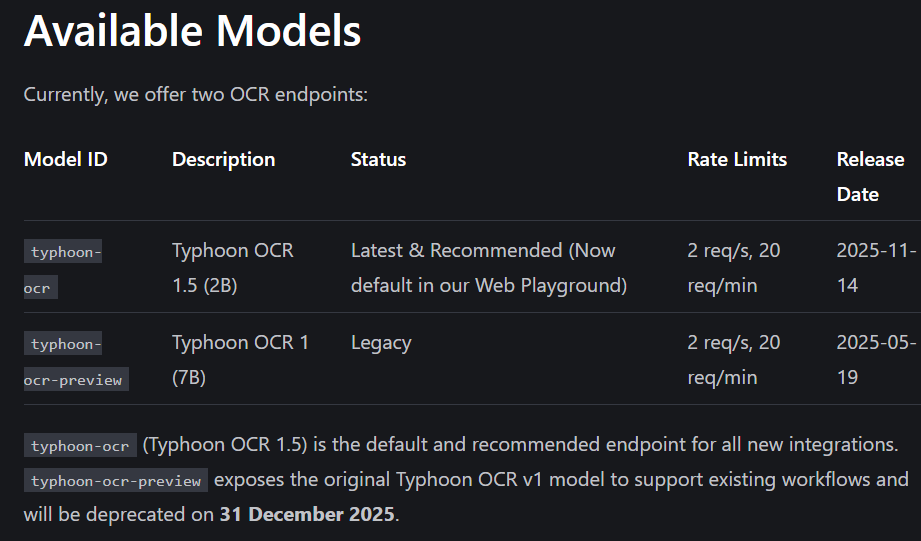

[ref: https://docs.opentyphoon.ai/en/]

This notebook uses **Typhoon OCR 1.5 (2B)** (launched November 14, 2025, by **SCB10X**), which is developed on top of **Qwen3-VL 2B**, a Vision-Language Model designed for robust document understanding.

### Key Capabilities

Typhoon OCR goes beyond plain text extraction.  
It preserves **document structure and layout** by returning rich, structured outputs, including:

- **Markdown** – general text content  
- **HTML** – tables, including complex layouts and merged cells  
- **`<figure>`** – images, charts, and diagrams  
  - *Example:*  
    `<figure> A bar chart comparing domestic and export revenue growth between Q1 and Q2 2025. </figure>`
- **LaTeX** – mathematical expressions  
  - *Example:*  
    `$$ \text{Profit Margin} = \frac{\text{Net Profit}}{\text{Total Revenue}} \times 100 $$`
- **`<page_number>`** – page indexing  
  - *Example:*  
    `<page_number>1</page_number>`

### Supported File Formats:
- Images: `PNG`, `JPEG`
- Documents: `PDF`

## Data Preparation

Load Image 1

In [ ]:
!wget https://www.finearts.go.th/storage/contents/2024/01/detail_image/Je55JmRtmkhgmkWf2G5qBsoK71TdJy51Ly0POYrG.jpg

Load Image 2

In [ ]:
!wget https://static.naewna.com/uploads/news/gallery/source/521538.jpg

See Image 1 (Stories/Tales)

In [ ]:
from IPython.display import Image, Markdown
story_tales = '/content/Je55JmRtmkhgmkWf2G5qBsoK71TdJy51Ly0POYrG.jpg'
Image(story_tales)

See Image 2 (Electricity Bill)

In [ ]:
electricity_bill = '/content/521538.jpg'
Image(electricity_bill)

Load PDF 1 (Student Fee - Chulalongkorn University Document)

In [ ]:
!wget https://web.reg.chula.ac.th/NewStudyFee_2563.pdf --no-check-certificate

Load PDF 2 (Revenue Department Annoucement)

In [ ]:
!wget https://www.rd.go.th/fileadmin/download/jortor/62896/pak1-24072568-listname1.pdf

## Method 1: via API

Note: The free tier has a rate limit of `2 requests per second` and `20 requests per minute`.

You can get an API key from https://playground.opentyphoon.ai/

In [ ]:
import os
from getpass import getpass
os.environ['TYPHOON_OCR_API_KEY'] = getpass('API Key : ')

Inference : Image 1 (Story / Tales)

In [ ]:
from typhoon_ocr import ocr_document

markdown_1 = ocr_document(
    pdf_or_image_path=story_tales,
    model = "typhoon-ocr",
)

Markdown(markdown_1) # Markdown printed or you can see the raw text by print(markdown_1)

In [ ]:
print(markdown_1)

Inference : Image 2 (Electricity Bill)

In [ ]:
markdown_2 = ocr_document(
    pdf_or_image_path=electricity_bill,
    model = "typhoon-ocr",
)

Markdown(markdown_2) # Markdown printed or you can see the raw text by print(markdown_2)

If you check the raw output, the table content will appear under the `<table>` tag.

In [ ]:
print(markdown_2)

Inference : PDF (Student Fee - Chulalongkorn University Document)

In [ ]:
markdown_3 = ocr_document(
    pdf_or_image_path="NewStudyFee_2563.pdf",
    page_num=2 # Process page 2 of a PDF (default is 1, always 1 for images)
)

Markdown(markdown_3)

If you check the raw output, the table content will appear under the `<table>` tag.

In [ ]:
print(markdown_3)

Inference : PDF (Revenue Department Annoucement)

In [ ]:
markdown_4 = ocr_document(
    pdf_or_image_path="pak1-24072568-listname1.pdf",
    page_num=1 # Process page 2 of a PDF (default is 1, always 1 for images)
)

Markdown(markdown_4)

If you check the raw output, the table content will appear under the `<table>` tag.

In [ ]:
print(markdown_4)

## Method 2: via HuggingFace (GPU Required)
- Details: https://huggingface.co/typhoon-ai/typhoon-ocr1.5-2b
- Google colab provides a free-tier gpu (T4).
- You can switch from CPU to GPU via the `settings menu (top-right corner)` → `Change runtime type` → `T4 GPU`.

Required prompt.

**`Remark`**: This model is intended to be used with a **specific prompt only**; **it will not work** with any other prompts.


In [ ]:
prompt_ocrv2 = """
Extract all text from the image.

Instructions:
- Only return the clean Markdown.
- Do not include any explanation or extra text.
- You must include all information on the page.

Formatting Rules:
- Tables: Render tables using <table>...</table> in clean HTML format.
- Equations: Render equations using LaTeX syntax with inline ($...$) and block ($$...$$).
- Images/Charts/Diagrams: Wrap any clearly defined visual areas (e.g. charts, diagrams, pictures) in:

<figure>
Describe the image's main elements (people, objects, text), note any contextual clues (place, event, culture), mention visible text and its meaning, provide deeper analysis when relevant (especially for financial charts, graphs, or documents), comment on style or architecture if relevant, then give a concise overall summary. Describe in English.
</figure>

- Page Numbers: Wrap page numbers in <page_number>...</page_number> (e.g., <page_number>14</page_number>).
- Checkboxes: Use ☐ for unchecked and ☑ for checked boxes.
    """

 Required the image resizing function

In [ ]:
def resize(img, max_size):
        width, height = img.size
        # Only resize if one dimension exceeds max_size
        if width > 300 or height > 300:
            if width >= height:
                # scale width to max_size
                scale = max_size / float(width)
                new_size = (max_size, int(height * scale))
            else:
                # scale height to max_size
                scale = max_size / float(height)
                new_size = (int(width * scale), max_size)

            img = img.resize(new_size, Image.Resampling.LANCZOS)
            print(f"Original {width, height} ==> Resized {img.size}")
            return img
        else:
            return img  # no resize


Load the model to the instance.

In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor
from PIL import Image

from huggingface_hub import login

model = AutoModelForImageTextToText.from_pretrained(
    "scb10x/typhoon-ocr1.5-2b", dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("scb10x/typhoon-ocr1.5-2b")

It's important to resize the image because the model is trained with a fixed image dimension of 1800 px.


In [ ]:
image = electricity_bill # @param ["story_tales","electricity_bill"] {"type":"raw"}
from PIL import Image

img = Image.open(image)
img = resize(img, 1800)

messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": img,
                },
                {
                    "type": "text",
                    "text": prompt_ocrv2
                }
            ],
        }
    ]

In [ ]:
# Preparation for inference
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

This may take a long time (~3 minutes per inference) on a T4 GPU.

In [ ]:
# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=10000)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

In [ ]:
from IPython.display import display, HTML, Markdown

display(img)
display(Markdown(output_text[0]))